# Clinical Trials EDA
Exploratory analysis of cleaned studies from `clinical_trials.db`.

In [117]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from query import load_all

df = load_all()
print(f"{len(df):,} studies loaded")
df.head(3)

df = df[df['phase2'] == True]
print(f"{len(df):,} phase 2 studies")

89 studies loaded
42 phase 2 studies


## Status breakdown

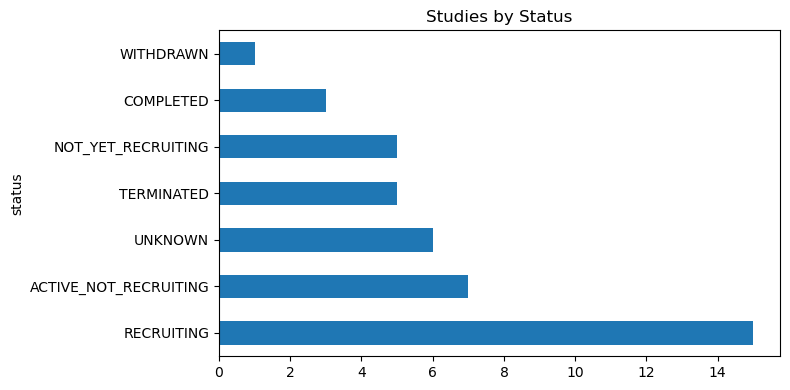

In [74]:
df['status'].value_counts().plot(kind='barh', figsize=(8, 4), title='Studies by Status')
plt.tight_layout()
plt.show()

## Phase distribution

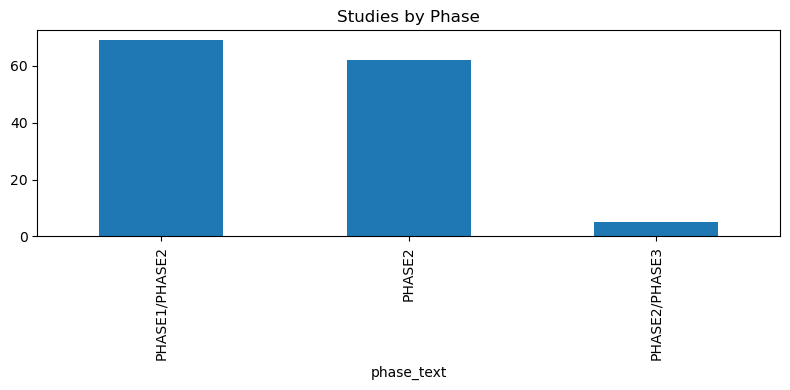

In [65]:
phase_order = ['EARLY_PHASE1', 'PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4', 'NA', 'missing']
# assert set(df['phase_text'].dropna().unique()).issubset(set(phase_order)), "Unexpected phase values found"
# assert set(phase_order).issubset(set(df['phase_text'].fillna('missing').unique())), "Phase order contains values not found in data"

counts = df['phase_text'].fillna('missing').value_counts()
counts = counts.reindex([p for p in phase_order if p in counts.index])

counts.plot(kind='bar', figsize=(8, 4), title='Studies by Phase')
plt.tight_layout()
plt.show()

## Enrollment histogram

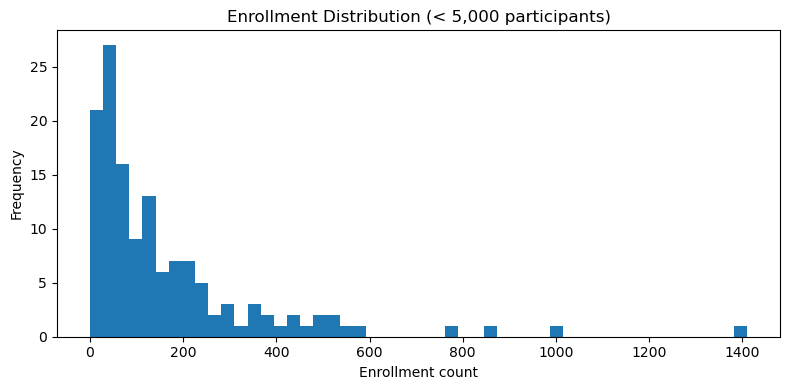

count     136.000000
mean      163.669118
std       205.326228
min         0.000000
25%        37.000000
50%        96.500000
75%       205.250000
max      1410.000000
Name: enrollment, dtype: float64
Number of studies with 0 enrollment: 5


In [66]:
enrollment = df['enrollment'].dropna()
enrollment[(enrollment < 5000)].plot(
    kind='hist', bins=50, figsize=(8, 4),
    title='Enrollment Distribution (< 5,000 participants)'
)
plt.xlabel('Enrollment count')
plt.tight_layout()
plt.show()
print(enrollment.describe())
print(f"Number of studies with 0 enrollment: {(enrollment == 0).sum()}")

## Trials opened per year

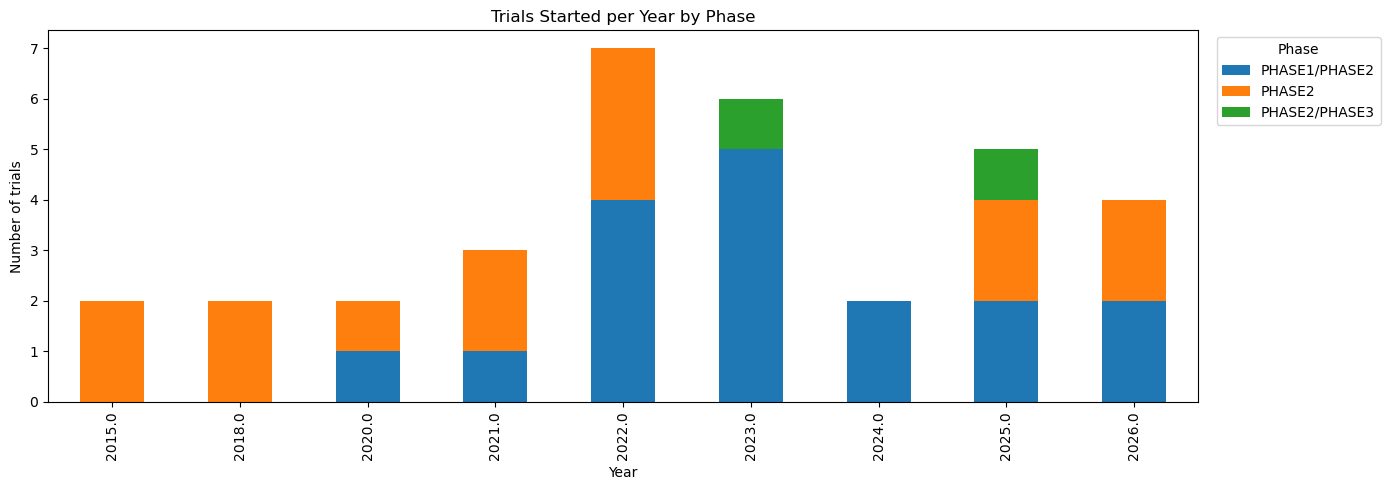

In [76]:
df['start_year'] = pd.to_datetime(df['start_date'], errors='coerce').dt.year

by_year_phase = (
    df
    .groupby(['start_year', df['phase_text'].fillna('missing')])
    .size()
    .unstack(fill_value=0)
)

by_year_phase.plot(kind='bar', stacked=True, figsize=(14, 5), title='Trials Started per Year by Phase')
plt.xlabel('Year')
plt.ylabel('Number of trials')
plt.legend(title='Phase', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Geographic breakdown — trials by country

21 unique countries


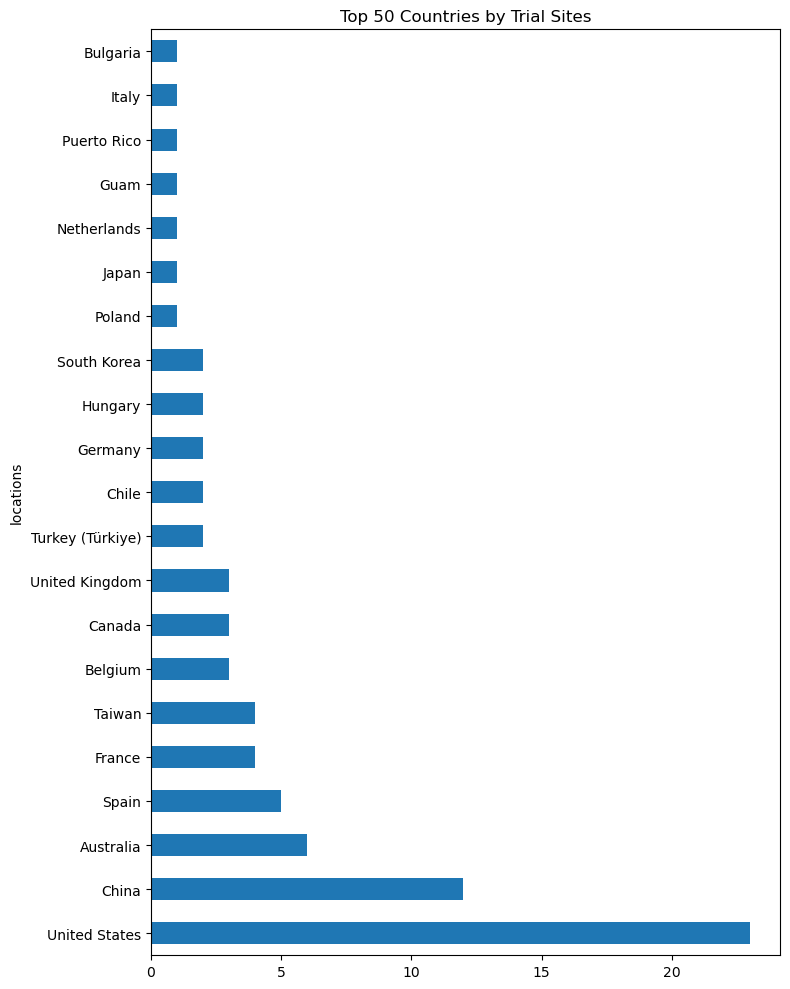

In [77]:
# Each study can have many locations — explode them out
locs = df['locations'].dropna().apply(json.loads)
study_countries = locs.apply(lambda loc_set: {loc.get('country') for loc in loc_set}) # set of countries per study, so a country can only be counted once per study
countries = set(study_countries.explode().dropna()) # nan come from missing locations, many are widthdrawn studies with no locations
print(len(countries), "unique countries")
study_countries.explode().value_counts().head(50).plot(
    kind='barh', figsize=(8, 10), title='Top 50 Countries by Trial Sites'
)
plt.tight_layout()
plt.show()

## Geographic breakdown — US trials by state

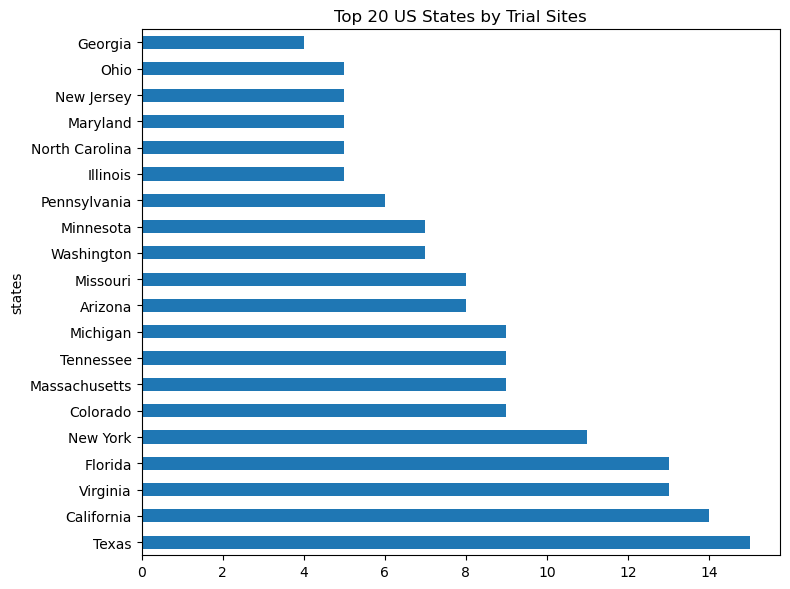

In [81]:
locs = df['locations'].dropna().apply(json.loads)
locs = locs.to_frame(name='json')
locs['countries'] = locs.apply(lambda row: {loc.get('country') for loc in row['json']}, axis=1)
locs['states'] = locs.apply(lambda row: {loc.get('state') for loc in row['json']}, axis=1)

# normalized trials with multiple sites in same state
us = locs[locs['countries'].apply(lambda x: 'United States' in x)].dropna(subset=['states'])
us['states'].explode().value_counts().head(20).plot(
    kind='barh', figsize=(8, 6), title='Top 20 US States by Trial Sites'
)
plt.tight_layout()
plt.show()

# Sites in EU and US

In [82]:
euAndUs_contries = [
    "Austria",
    "Belgium",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Denmark",
    "Estonia",
    "Finland",
    "France",
    "Germany",
    "Greece",
    "Hungary",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Malta",
    "Netherlands",
    "Poland",
    "Portugal",
    "Romania",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "United States"
]

eu = locs[locs['countries'].apply(lambda x: any(c in euAndUs_contries for c in x))]
print(len(eu), "studies with EU or US sites")

# sites = pd.json_normalize(df['locations'].dropna().apply(json.loads).explode())
# print(sites.shape, sites.head())

# print(len(eu), "studies with EU sites")
# print(eu['countries'])

26 studies with EU or US sites


## Sponsor class breakdown

Number of unique sponsors: 101


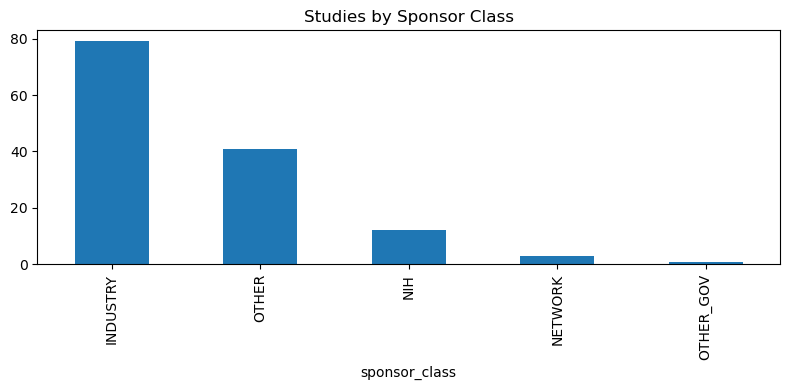

In [69]:
df['sponsor_class'].value_counts().plot(
    kind='bar', figsize=(8, 4), title='Studies by Sponsor Class'
)
# print(set(df['sponsor']))
print("Number of unique sponsors: %s" % len(set(df['sponsor'])))
plt.tight_layout()
plt.show()

## Primary and Total outcomes per study

In [36]:
# n_primary = df['primary_outcomes'].apply(lambda x: -1 if pd.isna(x) else len(json.loads(x)))
print("Number of studies without primary outcomes:", df['primary_outcomes'].isna().sum())

Number of studies without primary outcomes: 0


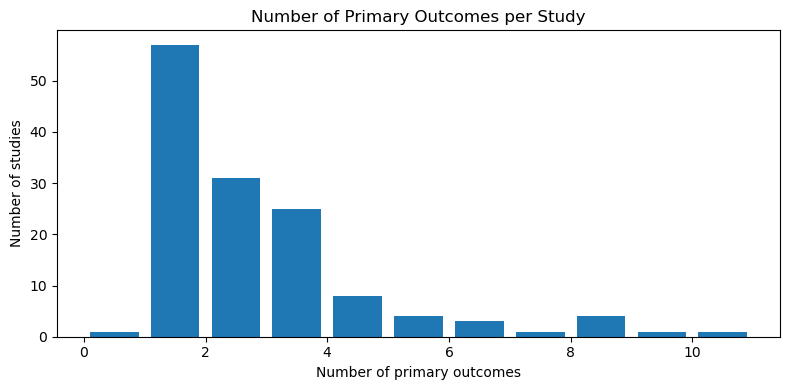

count    136.000000
mean       2.367647
std        1.857154
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       10.000000
Name: primary_outcomes, dtype: float64


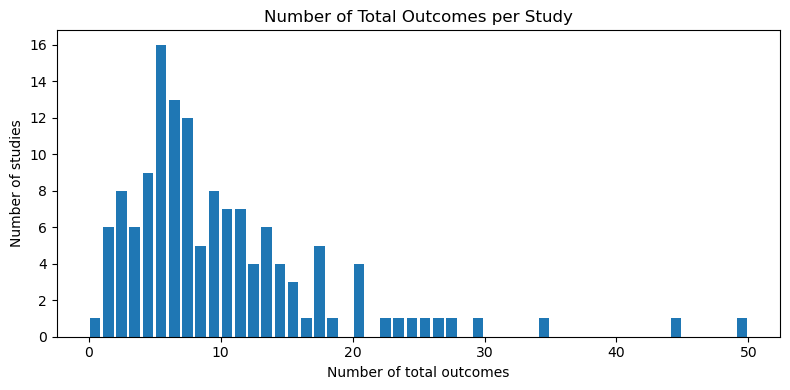

count    136.000000
mean       9.602941
std        7.837497
min        0.000000
25%        5.000000
50%        7.000000
75%       12.250000
max       49.000000
dtype: float64


In [70]:
n_primary = df['primary_outcomes'].apply(lambda x: len(json.loads(x)))
n_total = n_primary + df['secondary_outcomes'].dropna().apply(lambda x: len(json.loads(x)))

n_primary.plot(kind='hist', bins=range(0, n_primary.max() + 2), rwidth=0.8, figsize=(8, 4),
               title='Number of Primary Outcomes per Study', xlabel='Number of primary outcomes', ylabel='Number of studies')
plt.tight_layout()
plt.show()
print(n_primary.describe())

n_total.plot(kind='hist', bins=range(0, n_total.max() + 2), rwidth=0.8, figsize=(8, 4),
                 title='Number of Total Outcomes per Study', xlabel='Number of total outcomes', ylabel='Number of studies')
plt.tight_layout()
plt.show()
print(n_total.describe())

In [72]:
# no_primary = df['primary_outcomes'].apply(lambda x: len(json.loads(x)))
if (df['primary_outcomes'].isna().sum() > 0):
    d = df[['primary_outcomes', 'status']].copy()
    d['n_primary'] = d['primary_outcomes'].apply(lambda x: len(json.loads(x)))
    d[d['n_primary'] == 0]['status'].value_counts().plot(
        kind='bar', figsize=(8, 4), title='Status of Studies with No Primary Outcomes'
    )
    plt.tight_layout()
    plt.show()
# why are there complete ones with no outocmes??? look into it

In [71]:
df[df['phase2'] == True].shape

(136, 28)

# Enrollment Rate per site estimate

In [123]:
enrol_df = df[(df["enrollment"] > 0) & (df['start_date_type'] == 'ACTUAL')]
print(f"Number of studies with enrollment > 0 and actual start date: {enrol_df.shape[0]}")
start = pd.to_datetime(enrol_df['start_date'], format='mixed')
primary_end = pd.to_datetime(enrol_df['primary_completion_date'], format='mixed')
last_post = pd.to_datetime(enrol_df['last_update_post'], format='mixed')
end = primary_end.where(enrol_df['primary_completion_date_type'] == 'ACTUAL', last_post)
elapsed = (end - start) 
elapsed_days = elapsed.dt.total_seconds() / (24 * 3600)


Number of studies with enrollment > 0 and actual start date: 32


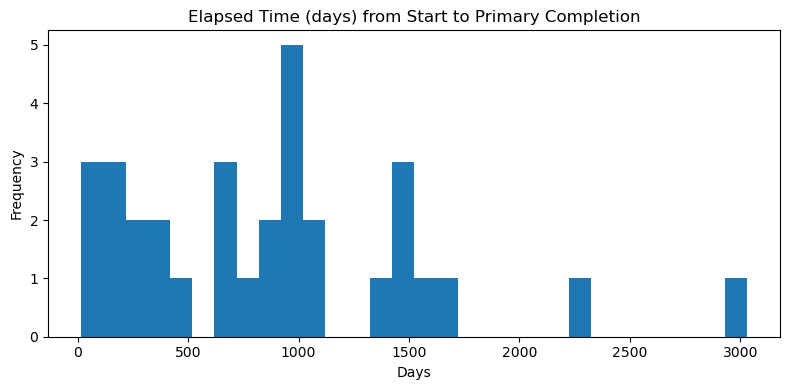

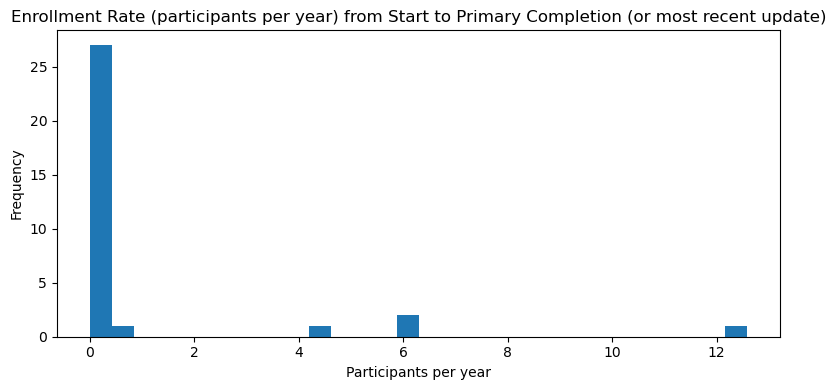

count    32.000000
mean      0.980263
std       2.671199
min       0.000191
25%       0.013909
50%       0.036470
75%       0.171733
max      12.586207
dtype: float64


In [125]:

elapsed_days.plot(
    kind='hist',
    bins=30,
    figsize=(8, 4),
    title='Elapsed Time (days) from Start to Primary Completion'
)
plt.xlabel('Days')
plt.tight_layout()
plt.show()
rate = enrol_df['enrollment'] / (elapsed.dt.total_seconds() / (365 * 24 * 60 * 60)) / enrol_df['locations'].apply(len)
rate.plot(
    kind='hist',
    bins=30,
    figsize=(8, 4),
    title='Enrollment Rate (participants per year) from Start to Primary Completion (or most recent update)'
)
plt.xlabel('Participants per year')
plt.tight_layout()
plt.show()
print(rate.describe())

In [ ]:
print(f"ACTUAL primary_completion_date_type: {enrol_df[enrol_df['primary_completion_date_type'] == 'ACTUAL'].shape}")
print(f"ESTIMATED primary_completion_date_type: {enrol_df[enrol_df['primary_completion_date_type'] == 'ESTIMATED'].shape}")

ACTUAL primary_completion_date_type: (10, 32)
ESTIMATED primary_completion_date_type: (31, 32)


In [133]:
enrol_df_2 = df[(df["enrollment"] > 0) & (df['start_date_type'] == 'ESTIMATED')]
print(f"Number of studies with enrollment > 0 and estimated start date: {enrol_df_2.shape[0]}")
enrol_df_2[['enrollment', 'start_date', 'primary_completion_date', 'start_date_type', 'primary_completion_date_type', 'last_update_post', 'status']].head(5)

Number of studies with enrollment > 0 and estimated start date: 5


,enrollment,start_date,primary_completion_date,start_date_type,primary_completion_date_type,last_update_post,status
2,12,2026-03,2027-03,ESTIMATED,ESTIMATED,2025-11-25,NOT_YET_RECRUITING
17,30,2026-02,2029-10,ESTIMATED,ESTIMATED,2026-02-27,NOT_YET_RECRUITING
29,15,2026-01-01,2030-12-31,ESTIMATED,ESTIMATED,2026-01-06,NOT_YET_RECRUITING
34,61,2026-01-31,2027-12-31,ESTIMATED,ESTIMATED,2026-02-17,NOT_YET_RECRUITING
53,120,2024-12,2026-08,ESTIMATED,ESTIMATED,2024-12-09,NOT_YET_RECRUITING


In [140]:
enrol_df = df[(df["enrollment"] > 0) & (df['enrollment_type'] == 'ACTUAL')]
print(f"Number of studies with enrollment > 0 and actual enrollment: {enrol_df_2.shape[0]}")
enrol_df[['nct_id', 'enrollment', 'start_date', 'primary_completion_date', 'start_date_type', 'primary_completion_date_type', 'last_update_post', 'status']].head(20)

Number of studies with enrollment > 0 and actual enrollment: 12


,nct_id,enrollment,start_date,primary_completion_date,start_date_type,primary_completion_date_type,last_update_post,status
0,NCT02387216,153,2015-02-01,2019-01-02,ACTUAL,ACTUAL,2021-10-12,TERMINATED
30,NCT04152499,1410,2020-02-28,2026-12-31,ACTUAL,ESTIMATED,2026-05-11,ACTIVE_NOT_RECRUITING
31,NCT05585320,209,2022-10-31,2026-06,ACTUAL,ESTIMATED,2025-09-02,ACTIVE_NOT_RECRUITING
44,NCT01997775,13,2013-08,2016-06,None,ACTUAL,2016-09-30,TERMINATED
46,NCT04538378,4,2021-07-07,2023-03-22,ACTUAL,ACTUAL,2025-01-27,TERMINATED
51,NCT04280081,77,2020-03-16,2021-03-25,ACTUAL,ACTUAL,2026-04-24,ACTIVE_NOT_RECRUITING
58,NCT06208124,30,2024-02-27,2025-04-30,ACTUAL,ACTUAL,2025-05-28,COMPLETED
75,NCT04902040,19,2021-04-14,2025-02-27,ACTUAL,ACTUAL,2026-04-30,TERMINATED
78,NCT04439292,35,2015-08-12,2023-11-27,ACTUAL,ACTUAL,2026-04-13,ACTIVE_NOT_RECRUITING
79,NCT00960999,94,2009-11,2012-08,ACTUAL,ACTUAL,2020-03-04,COMPLETED


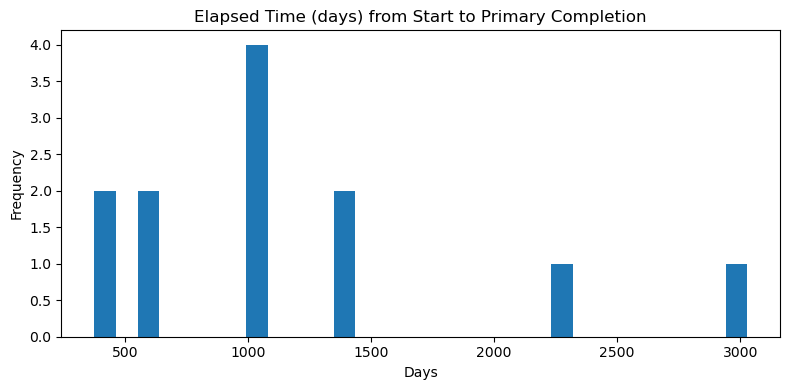

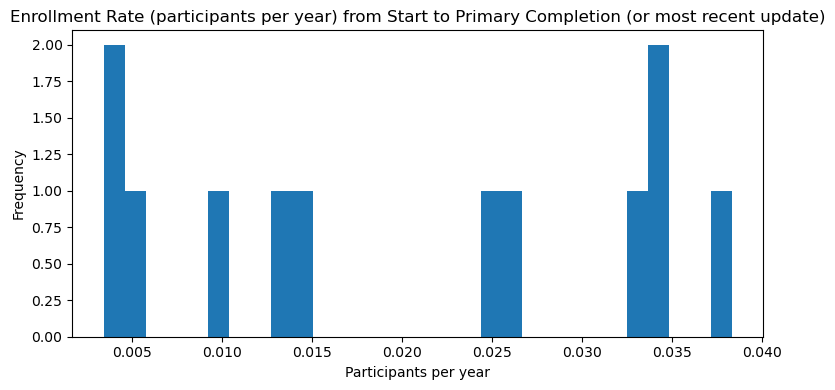

count    12.000000
mean      0.020063
std       0.013241
min       0.003438
25%       0.008293
50%       0.019409
75%       0.033607
max       0.038321
dtype: float64


In [139]:
start = pd.to_datetime(enrol_df['start_date'], format='mixed')
primary_end = pd.to_datetime(enrol_df['primary_completion_date'], format='mixed')
last_post = pd.to_datetime(enrol_df['last_update_post'], format='mixed')
end = primary_end.where(enrol_df['primary_completion_date_type'] == 'ACTUAL', last_post)
elapsed = (end - start) 
elapsed_days = elapsed.dt.total_seconds() / (24 * 3600)
elapsed_days.plot(
    kind='hist',
    bins=30,
    figsize=(8, 4),
    title='Elapsed Time (days) from Start to Primary Completion'
)
plt.xlabel('Days')
plt.tight_layout()
plt.show()
rate = enrol_df['enrollment'] / (elapsed.dt.total_seconds() / (365 * 24 * 60 * 60)) / enrol_df['locations'].apply(len)
rate.plot(
    kind='hist',
    bins=30,
    figsize=(8, 4),
    title='Enrollment Rate (participants per year) from Start to Primary Completion (or most recent update)'
)
plt.xlabel('Participants per year')
plt.tight_layout()
plt.show()
print(rate.describe())